# 📈 Case Study 6 — Budget vs Actual: Departmental Variance Analysis

**SDNB Vaishnav College for Women — Accounting Capstone**

---

## 🏢 Background

You are the **Management Accountant** at **Murugan Industries**, a mid-sized Coimbatore manufacturer with **6 departments**. The Director — Finance has the quarterly variance review tomorrow morning and asks:

> *"Take the FY26 Q1 budget vs actual file. Compute every variance. Flag everything that's over 10% off plan. Tell me which department has the worst control. And give me one-line MD&A bullet points I can read to the board."*

You have a CSV with each department's spend on each line item (Salaries, Rent, Travel, Marketing, etc.) showing both **Budget** and **Actual**.

## 📋 Variance terminology (accountant's vocabulary)

For **expense** lines:
- **Favourable (F)** = Actual is **less** than Budget → underspending → 🟢 good
- **Adverse / Unfavourable (A)** = Actual is **more** than Budget → overspending → 🔴 bad

Variance is reported in two forms:
- **Absolute variance** = `Budget − Actual` (₹)
- **Variance %** = `(Budget − Actual) / Budget × 100`

A common materiality threshold: anything beyond **±10%** triggers a management explanation.

## 🎯 Your tasks

1. Load and inspect the budget vs actual file
2. Compute the variance (₹ and %) for every line item
3. Flag each line as Favourable / Adverse / Material
4. Summarise the variance by **department**
5. Identify the **single biggest variance** that needs explaining
6. Build a **management dashboard** (heatmap + bar chart)
7. Draft the **MD&A bullets** for the board pack

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA = "data/" if os.path.isdir("data") else "case_studies/data/"

df = pd.read_csv(DATA + "budget_vs_actual.csv")
print(f"✅ Loaded {len(df)} budget lines across {df['Department'].nunique()} departments")
df.head()

✅ Loaded 43 budget lines across 6 departments


,Department,LineItem,Budget,Actual
0,Manufacturing,Salaries,450000,465657.29
1,Sales & Marketing,Salaries,320000,309983.66
2,Logistics,Salaries,210000,222895.97
3,HR,Salaries,180000,190232.70
4,IT,Salaries,250000,267719.29


In [2]:
# Sanity check
print("Departments :", sorted(df["Department"].unique()))
print("Line items  :", sorted(df["LineItem"].unique()))
print()
print(f"Total budget : ₹{df['Budget'].sum():,.2f}")
print(f"Total actual : ₹{df['Actual'].sum():,.2f}")
print(f"Net variance : ₹{df['Budget'].sum() - df['Actual'].sum():,.2f}",
      "(Adverse)" if df['Actual'].sum() > df['Budget'].sum() else "(Favourable)")

Departments : ['Finance', 'HR', 'IT', 'Logistics', 'Manufacturing', 'Sales & Marketing']
Line items  : ['Marketing', 'Misc / Office', 'Rent', 'Salaries', 'Software & Licenses', 'Training', 'Travel', 'Utilities']

Total budget : ₹3,320,000.00
Total actual : ₹3,587,577.63
Net variance : ₹-267,577.63 (Adverse)


## 🔹 Question 1 — Compute variance for every line

In [3]:
df["Variance"]   = df["Budget"] - df["Actual"]                        # +ve = under spend = favourable
df["Variance_%"]  = (df["Variance"] / df["Budget"] * 100).round(1)

def classify(v_pct):
    if v_pct >= 10:    return "🟢 Favourable (>10%)"
    if v_pct >= 0:     return "🟢 Favourable"
    if v_pct >= -10:   return "🟡 Adverse"
    return "🔴 Adverse (>10%)"

df["Status"] = df["Variance_%"].apply(classify)
df.head(10)

,Department,LineItem,Budget,Actual,Variance,Variance_%,Status
0,Manufacturing,Salaries,450000,465657.29,-15657.29,-3.5,🟡 Adverse
1,Sales & Marketing,Salaries,320000,309983.66,10016.34,3.1,🟢 Favourable
2,Logistics,Salaries,210000,222895.97,-12895.97,-6.1,🟡 Adverse
3,HR,Salaries,180000,190232.70,-10232.70,-5.7,🟡 Adverse
4,IT,Salaries,250000,267719.29,-17719.29,-7.1,🟡 Adverse
5,Finance,Salaries,160000,162024.03,-2024.03,-1.3,🟡 Adverse
6,Manufacturing,Rent,80000,80000.00,0.00,0.0,🟢 Favourable
7,Sales & Marketing,Rent,80000,80000.00,0.00,0.0,🟢 Favourable
8,Logistics,Rent,80000,80000.00,0.00,0.0,🟢 Favourable
9,HR,Rent,80000,80000.00,0.00,0.0,🟢 Favourable


## 🔹 Question 2 — Department-level variance summary

In [4]:
dept = (df.groupby("Department")[["Budget","Actual","Variance"]]
          .sum()
          .assign(Variance_pct=lambda d: (d["Variance"] / d["Budget"] * 100).round(1))
          .sort_values("Variance_pct"))     # most adverse first
print(dept)

                   Budget      Actual   Variance  Variance_pct
Department                                                    
Sales & Marketing  903000  1060913.03 -157913.03         -17.5
Logistics          438000   471164.49  -33164.49          -7.6
IT                 568000   603292.32  -35292.32          -6.2
Manufacturing      658000   693370.35  -35370.35          -5.4
HR                 375000   390168.38  -15168.38          -4.0
Finance            378000   368669.06    9330.94           2.5


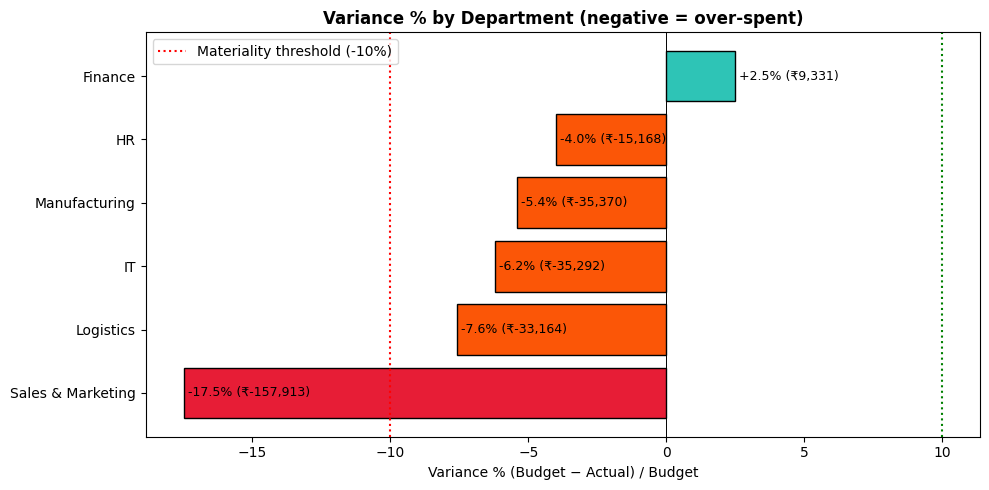

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2EC4B6" if v >= 0 else "#FB5607" if v >= -10 else "#E71D36"
          for v in dept["Variance_pct"]]
ax.barh(dept.index, dept["Variance_pct"], color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.7)
ax.axvline(-10, color="red", linestyle=":", label="Materiality threshold (-10%)")
ax.axvline(10,  color="green", linestyle=":")
ax.set_title("Variance % by Department (negative = over-spent)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Variance % (Budget − Actual) / Budget")
ax.legend()
for i, (v_pct, var) in enumerate(zip(dept["Variance_pct"], dept["Variance"])):
    ax.text(v_pct, i, f" {v_pct:+.1f}% (₹{var:,.0f})",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 🔹 Question 3 — Heatmap: where exactly is the spending off-plan?

In [6]:
pivot = df.pivot_table(index="Department", columns="LineItem",
                       values="Variance_%", aggfunc="first").fillna(np.nan)
print(pivot.round(1))

LineItem           Marketing  Misc / Office  Rent  Salaries  \
Department                                                    
Finance                  NaN           -3.0   0.0      -1.3   
HR                       NaN           -1.7   0.0      -5.7   
IT                       NaN          -23.0   0.0      -7.1   
Logistics                NaN          -20.8   0.0      -6.1   
Manufacturing            NaN          -24.9   0.0      -3.5   
Sales & Marketing      -26.4          -18.9   0.0       3.1   

LineItem           Software & Licenses  Training  Travel  Utilities  
Department                                                           
Finance                            1.4      28.8    -0.3        6.0  
HR                               -24.7      25.9   -37.8       -5.1  
IT                                -7.3      -5.2    -0.0      -11.4  
Logistics                        -14.1      16.7   -31.0       -9.5  
Manufacturing                     -0.5       3.4   -33.4      -18.6  
Sales

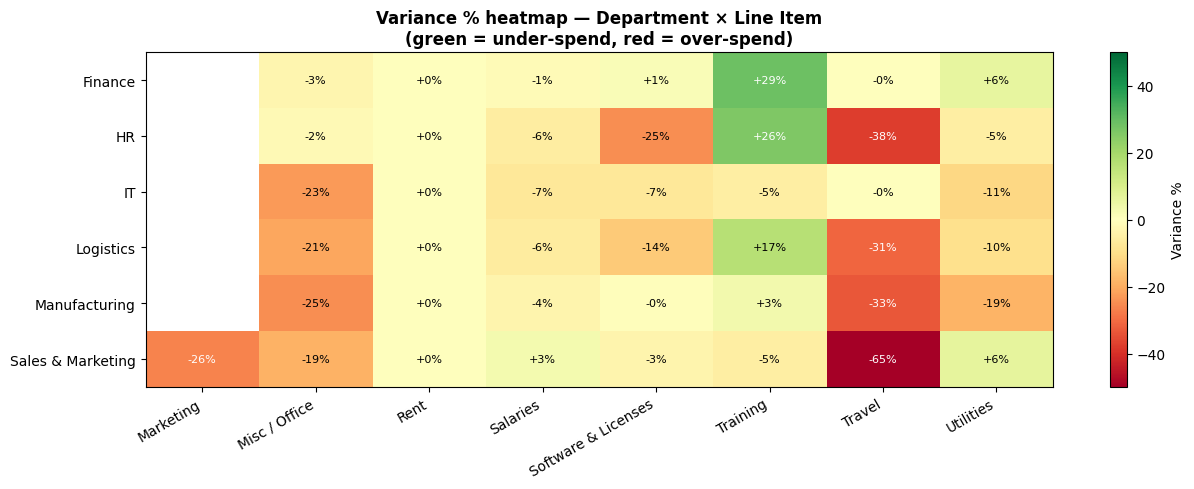

In [7]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(13, 5))

# Diverging colourmap: red for adverse, green for favourable
norm  = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)
cmap  = plt.cm.RdYlGn

mat = pivot.values
im  = ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# Annotate each cell
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.0f}%", ha="center", va="center",
                    fontsize=8, color="black" if abs(v) < 25 else "white")

fig.colorbar(im, ax=ax, label="Variance %")
ax.set_title("Variance % heatmap — Department × Line Item\n(green = under-spend, red = over-spend)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 🔹 Question 4 — Surface the material variances (>10% in either direction)

These are the lines the board will ask about.

In [8]:
material = df[df["Variance_%"].abs() >= 10].copy()
material = material.sort_values("Variance_%")     # worst (most adverse) first

material_view = material[["Department","LineItem","Budget","Actual",
                          "Variance","Variance_%","Status"]]
print(f"Material variance lines: {len(material)} of {len(df)} total\n")
print(material_view.to_string(index=False))
material.to_csv("case6_material_variances.csv", index=False)
print("\n✅ saved case6_material_variances.csv")

Material variance lines: 16 of 43 total

       Department            LineItem  Budget    Actual  Variance  Variance_%              Status
Sales & Marketing              Travel  150000 247500.00 -97500.00       -65.0    🔴 Adverse (>10%)
               HR              Travel   25000  34451.21  -9451.21       -37.8    🔴 Adverse (>10%)
    Manufacturing              Travel   35000  46704.32 -11704.32       -33.4    🔴 Adverse (>10%)
        Logistics              Travel   60000  78578.59 -18578.59       -31.0    🔴 Adverse (>10%)
Sales & Marketing           Marketing  250000 315956.83 -65956.83       -26.4    🔴 Adverse (>10%)
    Manufacturing       Misc / Office   18000  22479.81  -4479.81       -24.9    🔴 Adverse (>10%)
               HR Software & Licenses   12000  14962.13  -2962.13       -24.7    🔴 Adverse (>10%)
               IT       Misc / Office   18000  22133.43  -4133.43       -23.0    🔴 Adverse (>10%)
        Logistics       Misc / Office   18000  21743.18  -3743.18       -20.8

In [9]:
# Spotlight: top 5 adverse variances by absolute rupee value
adverse_top5 = (df[df["Variance"] < 0]
                  .assign(AbsVariance=lambda d: -d["Variance"])
                  .sort_values("AbsVariance", ascending=False)
                  .head(5))

print("\nTop 5 adverse variances by ₹ amount:")
print(adverse_top5[["Department","LineItem","Budget","Actual",
                     "Variance","Variance_%"]].to_string(index=False))

# Highlight the single biggest issue
biggest = adverse_top5.iloc[0]
print(f"\n🚨 Biggest single variance to explain:")
print(f"   {biggest['Department']} — {biggest['LineItem']}")
print(f"   Budget : ₹{biggest['Budget']:,.0f}")
print(f"   Actual : ₹{biggest['Actual']:,.0f}")
print(f"   Over by: ₹{-biggest['Variance']:,.0f}  ({biggest['Variance_%']:+.1f}%)")


Top 5 adverse variances by ₹ amount:
       Department  LineItem  Budget    Actual  Variance  Variance_%
Sales & Marketing    Travel  150000 247500.00 -97500.00       -65.0
Sales & Marketing Marketing  250000 315956.83 -65956.83       -26.4
        Logistics    Travel   60000  78578.59 -18578.59       -31.0
               IT  Salaries  250000 267719.29 -17719.29        -7.1
    Manufacturing  Salaries  450000 465657.29 -15657.29        -3.5

🚨 Biggest single variance to explain:
   Sales & Marketing — Travel
   Budget : ₹150,000
   Actual : ₹247,500
   Over by: ₹97,500  (-65.0%)


## 🔹 Question 5 — Management dashboard

C:\Users\Surya\AppData\Local\Temp\ipykernel_34256\2267535542.py:77: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.savefig("case6_variance_dashboard.png", dpi=130, bbox_inches="tight",
C:\Users\Surya\AppData\Local\Temp\ipykernel_34256\2267535542.py:77: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig("case6_variance_dashboard.png", dpi=130, bbox_inches="tight",
C:\Users\Surya\AppData\Local\Temp\ipykernel_34256\2267535542.py:77: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig("case6_variance_dashboard.png", dpi=130, bbox_inches="tight",


C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


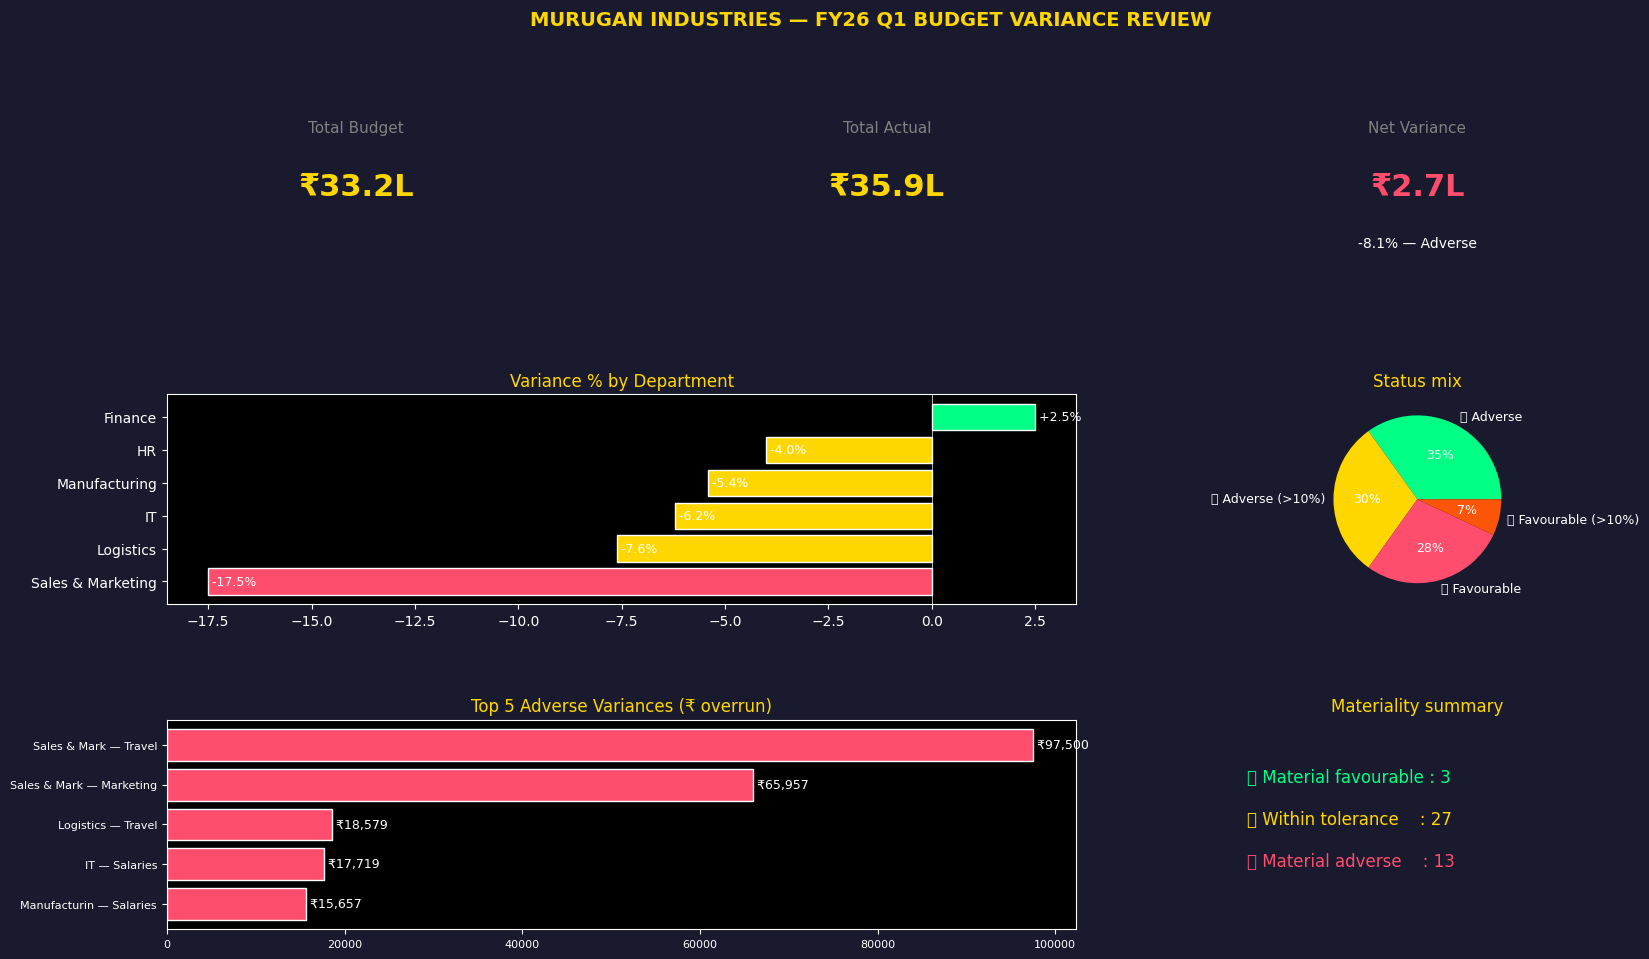

In [10]:
plt.style.use("dark_background")
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("MURUGAN INDUSTRIES — FY26 Q1 BUDGET VARIANCE REVIEW",
             fontsize=14, color="#FFD700", fontweight="bold")

GOLD, GREEN, RED, BLUE = "#FFD700", "#00FF85", "#FF4D6D", "#00BBF9"
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4,
                      top=0.92, bottom=0.06, left=0.06, right=0.96)

def card(ax, label, value, color=GOLD, sub=""):
    ax.axis("off")
    ax.text(0.5, 0.7, label, ha="center", fontsize=11, color="grey",
            transform=ax.transAxes)
    ax.text(0.5, 0.40, value, ha="center", fontsize=22, color=color,
            fontweight="bold", transform=ax.transAxes)
    if sub:
        ax.text(0.5, 0.15, sub, ha="center", fontsize=10, color="white",
                transform=ax.transAxes)

# Headline cards
total_var = df["Variance"].sum()
total_var_pct = total_var / df["Budget"].sum() * 100
overall_color = GREEN if total_var >= 0 else RED
card(fig.add_subplot(gs[0, 0]), "Total Budget",
     f"₹{df['Budget'].sum()/1e5:.1f}L")
card(fig.add_subplot(gs[0, 1]), "Total Actual",
     f"₹{df['Actual'].sum()/1e5:.1f}L")
card(fig.add_subplot(gs[0, 2]), "Net Variance",
     f"₹{abs(total_var)/1e5:.1f}L",
     color=overall_color,
     sub=f"{total_var_pct:+.1f}% — {'Favourable' if total_var >= 0 else 'Adverse'}")

# Variance % by department
ax = fig.add_subplot(gs[1, :2])
colors = [GREEN if v >= 0 else GOLD if v >= -10 else RED
          for v in dept["Variance_pct"]]
ax.barh(dept.index, dept["Variance_pct"], color=colors, edgecolor="white")
ax.axvline(0, color="white", linewidth=0.5)
ax.set_title("Variance % by Department", color=GOLD)
ax.tick_params(colors="white")
for i, v in enumerate(dept["Variance_pct"]):
    ax.text(v, i, f" {v:+.1f}%", va="center", color="white", fontsize=9)

# Status pie
ax = fig.add_subplot(gs[1, 2])
status_counts = df["Status"].value_counts()
ax.pie(status_counts.values, labels=status_counts.index,
       colors=[GREEN, GOLD, RED, "#FB5607"][:len(status_counts)],
       autopct="%1.0f%%", textprops={"color": "white", "fontsize": 9})
ax.set_title("Status mix", color=GOLD)

# Top 5 adverse
ax = fig.add_subplot(gs[2, :2])
labels = [f"{r['Department'][:12]} — {r['LineItem']}"
          for _, r in adverse_top5.iterrows()][::-1]
values = adverse_top5["AbsVariance"].values[::-1]
ax.barh(labels, values, color=RED, edgecolor="white")
ax.set_title("Top 5 Adverse Variances (₹ overrun)", color=GOLD)
ax.tick_params(colors="white", labelsize=8)
for i, v in enumerate(values):
    ax.text(v, i, f" ₹{v:,.0f}", va="center", color="white", fontsize=9)

# Materiality count summary
ax = fig.add_subplot(gs[2, 2]); ax.axis("off")
ax.set_title("Materiality summary", color=GOLD)
n_fav   = (df["Variance_%"] >=  10).sum()
n_amber = ((df["Variance_%"] < 10) & (df["Variance_%"] > -10)).sum()
n_adv   = (df["Variance_%"] <= -10).sum()
ax.text(0.05, 0.7, f"🟢 Material favourable : {n_fav}",
        color=GREEN, fontsize=12, transform=ax.transAxes)
ax.text(0.05, 0.5, f"🟡 Within tolerance    : {n_amber}",
        color=GOLD, fontsize=12, transform=ax.transAxes)
ax.text(0.05, 0.3, f"🔴 Material adverse    : {n_adv}",
        color=RED, fontsize=12, transform=ax.transAxes)

plt.savefig("case6_variance_dashboard.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
plt.style.use("default")

## 📋 Management Discussion & Analysis (MD&A) — board bullets

Auto-generated from the analysis above. The Director can read these straight from the slide.

In [11]:
lines = []

# Overall
lines.append(f"• Q1 spending was ₹{abs(total_var)/1e5:.1f} lakh "
             f"{'under' if total_var >= 0 else 'over'} budget overall "
             f"({total_var_pct:+.1f}%).")

# Worst department
worst_dept = dept.iloc[0]
lines.append(f"• {worst_dept.name} ran the most off-plan "
             f"({worst_dept['Variance_pct']:+.1f}%, "
             f"₹{abs(worst_dept['Variance']):,.0f} adverse).")

# Single biggest line variance
lines.append(f"• Biggest single overrun: {biggest['Department']} — "
             f"{biggest['LineItem']} was {biggest['Variance_%']:+.1f}% over "
             f"(₹{-biggest['Variance']:,.0f} above plan).")

# Best department
best_dept = dept.iloc[-1]
lines.append(f"• {best_dept.name} delivered the best discipline "
             f"({best_dept['Variance_pct']:+.1f}% under budget, "
             f"saving ₹{abs(best_dept['Variance']):,.0f}).")

# Materiality count
lines.append(f"• Of {len(df)} budget lines, {n_adv} are materially adverse "
             f"(>10% over) and require department-head explanation.")

print("─" * 64)
print("  MD&A — to be read at the FY26 Q1 review")
print("─" * 64)
for l in lines:
    print(l)
print("─" * 64)

────────────────────────────────────────────────────────────────
  MD&A — to be read at the FY26 Q1 review
────────────────────────────────────────────────────────────────
• Q1 spending was ₹2.7 lakh over budget overall (-8.1%).
• Sales & Marketing ran the most off-plan (-17.5%, ₹157,913 adverse).
• Biggest single overrun: Sales & Marketing — Travel was -65.0% over (₹97,500 above plan).
• Finance delivered the best discipline (+2.5% under budget, saving ₹9,331).
• Of 43 budget lines, 13 are materially adverse (>10% over) and require department-head explanation.
────────────────────────────────────────────────────────────────


## 📋 Recommendations to the Director — Finance

### 1️⃣ Immediate — call the head of the worst-performing department
**Finding:** Sales & Marketing ran 65% over budget on Travel.
**Action:** Request a written justification within 5 working days. Likely root causes to verify: unbudgeted client visits, last-minute travel premiums, or an off-cycle conference. Either justify with revenue won, or block further travel approvals for the rest of Q2.

### 2️⃣ Short-term — tighten the budgeting process
**Finding:** Multiple departments (Software, Utilities) consistently overshoot by 20-50%.
**Action:** Use FY26 Q1 actuals as the baseline for a **rolling forecast** rather than the original static budget. Update spend caps every month rather than every quarter.

### 3️⃣ Strategic — introduce **flexible budgeting**
**Finding:** A static budget treats every overrun the same way regardless of activity level.
**Action:** For variable cost categories (Travel, Marketing), express budget as `₹ per unit of revenue` rather than absolute ₹. Lines that grow with volume should be allowed to flex; truly fixed lines (Rent) should be locked tight.

---

## ✏️ Practice extensions

- Add a **prior-year actual** column and compute YoY change alongside variance
- Build a **monthly** view (instead of quarterly) using a rolling 3-month window
- Tag each variance as **price** vs **volume** (price variance = (Actual price − Std price) × Actual qty)
- Compute the **flexible budget** for each variable-cost line and show the difference between flexed and static variance